<a href="https://colab.research.google.com/github/olesya025/signal-clustering-final/blob/main/Final_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Введение

Данная работа посвящена автоматической кластеризации сигналов сцинтилляционного детектора. Сцинтилляционные детекторы используются для регистрации ионизирующего излучения в ядерной энергетике, радиационном контроле и физических экспериментах. При попадании частицы в детектор возникает вспышка света, которая преобразуется в электрический сигнал. Форма этого сигнала зависит от типа частицы: гамма-кванты и нейтроны по-разному взаимодействуют с веществом детектора.

Задача состоит в том, чтобы разделить 23479 сигналов на три кластера: два соответствуют разным типам частиц (гамма-кванты и нейтроны), третий — аномальным или неидентифицируемым сигналам. Решение выполняется методами машинного обучения без учителя, так как истинные метки сигналов неизвестны.

В работе проводится разведочный анализ данных, предобработка сигналов, извлечение признаков, эксперименты с различными методами кластеризации и формирование итогового файла для соревнования на Kaggle.

##Загрузка данных и первичный анализ

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install -q gdown
import gdown

file_id = "1KESjKG6IIH8PgsykdFxUms7Kkj9Zk_LY"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "signals.txt", quiet=False)

data_full = pd.read_csv('signals.txt', sep=' ', header=None, skipinitialspace=True)
print('Размер исходного набора:', data_full.shape)

# Удаляем служебные столбцы (первые 4 и последний 504)
signals = data_full.drop([0, 1, 2, 3, 504], axis=1)
signals.columns = [f'time_{i}' for i in range(500)]

print('Размер после удаления служебных столбцов:', signals.shape)
print('Первые 5 строк (первые 10 временных отсчётов):')
display(signals.iloc[:5, :10])

print('Проверка на пропуски:', signals.isnull().sum().sum())

Downloading...
From: https://drive.google.com/uc?id=1KESjKG6IIH8PgsykdFxUms7Kkj9Zk_LY
To: /content/signals.txt
100%|██████████| 71.3M/71.3M [00:00<00:00, 71.6MB/s]


Размер исходного набора: (23479, 505)
Размер после удаления служебных столбцов: (23479, 500)
Первые 5 строк (первые 10 временных отсчётов):


,time_0,time_1,time_2,time_3,time_4,time_5,time_6,time_7,time_8,time_9
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821


Проверка на пропуски: 0


Набор данных содержит 23479 сигналов. Каждый сигнал представлен 500 временными отсчётами. Пропуски отсутствуют. Значения амплитуд находятся в диапазоне примерно от 14800 до 14830 ADC, что говорит о необходимости вычитания базовой линии для выделения полезного сигнала.

##Визуальный анализ сигналов

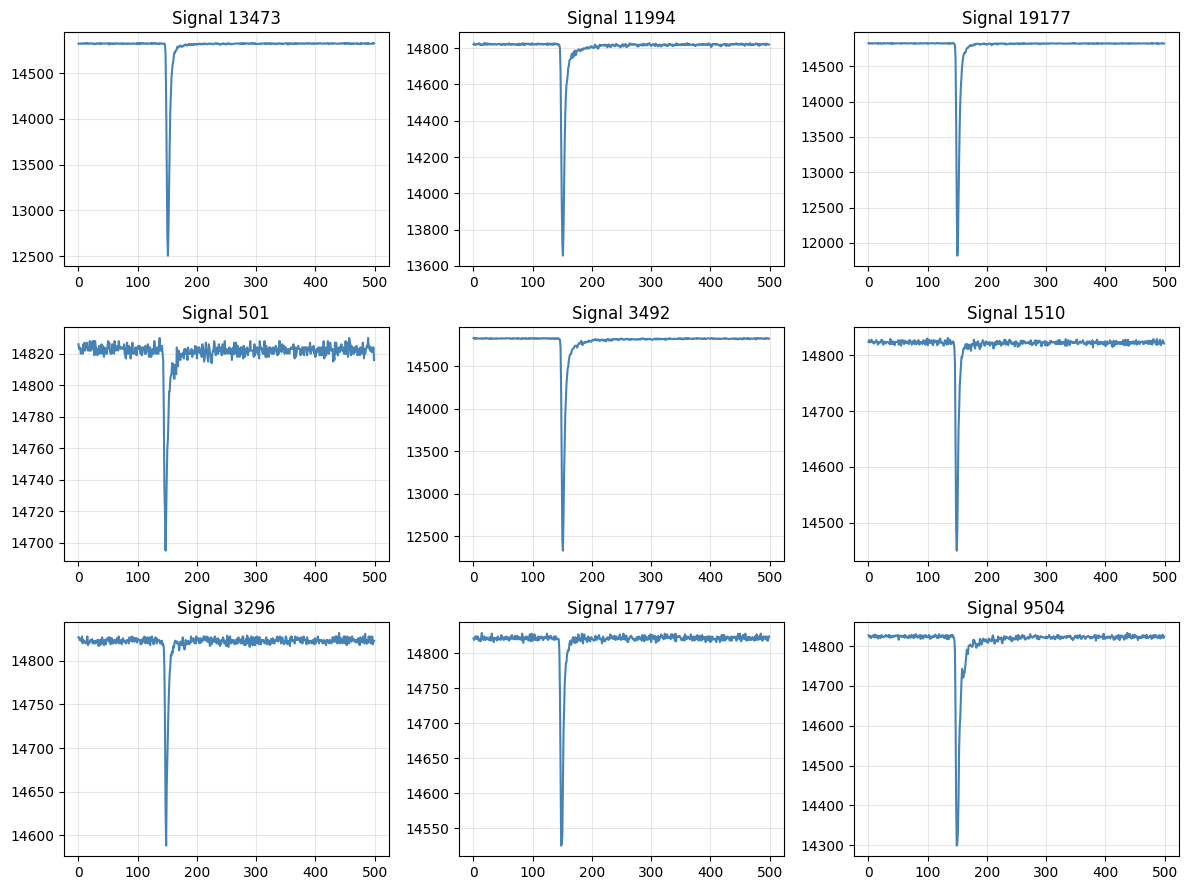

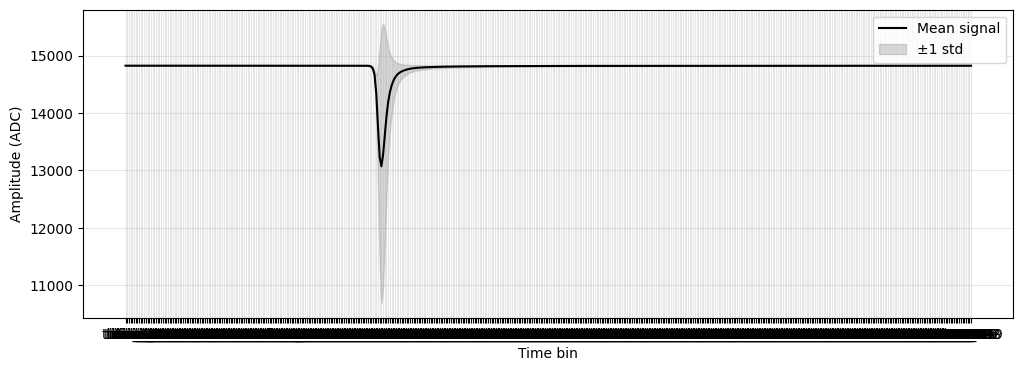

In [ ]:
np.random.seed(42)
sample = np.random.choice(signals.shape[0], 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, idx in enumerate(sample):
    axes[i//3, i%3].plot(signals.iloc[idx].values, color='steelblue')
    axes[i//3, i%3].set_title(f'Signal {idx}')
    axes[i//3, i%3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mean_signal = signals.mean(axis=0)
std_signal = signals.std(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(mean_signal, color='black', label='Mean signal')
plt.fill_between(range(500), mean_signal - std_signal, mean_signal + std_signal, alpha=0.3, color='gray', label='±1 std')
plt.xlabel('Time bin')
plt.ylabel('Amplitude (ADC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Сигналы выглядят как отрицательные импульсы. До события амплитуда держится примерно на одном уровне (около 14300-14400). В районе 150-170 отсчёта происходит резкое падение до 12500-12800, а потом сигнал медленно возвращается обратно.

Такая форма типична для сцинтилляционного детектора. Разные частицы по-разному затухают: у одних сигнал восстанавливается быстрее, у других — медленнее. Именно это различие мы будем использовать для кластеризации.

##EDA

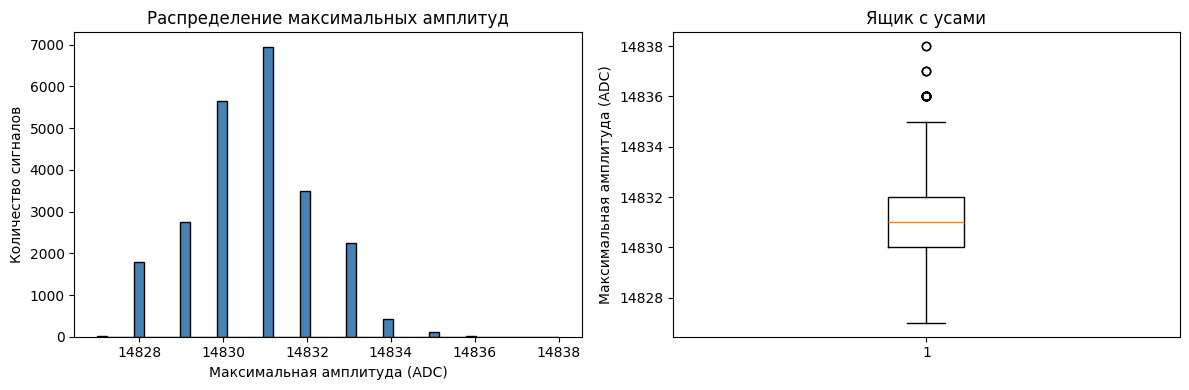

Средняя максимальная амплитуда: 14830.71
Медиана максимальной амплитуды: 14831.00
Стандартное отклонение: 1.46
Количество выбросов (амплитуда > 14835): 28
Базовая линия (первые 50 отсчётов): 14822.97 ± 0.86
Средняя корреляция между соседними отсчётами: 0.389


In [ ]:
max_vals = signals.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(max_vals, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Максимальная амплитуда (ADC)')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение максимальных амплитуд')

axes[1].boxplot(max_vals)
axes[1].set_ylabel('Максимальная амплитуда (ADC)')
axes[1].set_title('Ящик с усами')
plt.tight_layout()
plt.show()

print(f'Средняя максимальная амплитуда: {max_vals.mean():.2f}')
print(f'Медиана максимальной амплитуды: {max_vals.median():.2f}')
print(f'Стандартное отклонение: {max_vals.std():.2f}')
print(f'Количество выбросов (амплитуда > 14835): {np.sum(max_vals > 14835)}')

# Оценка базовой линии по первым 50 отсчётам
baseline_mean = signals.iloc[:, :50].mean(axis=1).mean()
baseline_std = signals.iloc[:, :50].mean(axis=1).std()
print(f'Базовая линия (первые 50 отсчётов): {baseline_mean:.2f} ± {baseline_std:.2f}')

# Корреляция между соседними отсчётами
corr_value = signals.corrwith(signals.shift(1, axis=1), axis=0).mean()
print(f'Средняя корреляция между соседними отсчётами: {corr_value:.3f}')

Максимальные амплитуды у большинства сигналов держатся примерно на одном уровне. Нашлось 28 сигналов с необычно высокими значениями — это возможные выбросы или шум.

Базовая линия почти не меняется, её можно смело вычитать. Корреляция между соседними точками положительная, но не слишком сильная. Значит, сигнал не случайный, у него есть форма и  её можно охарактеризовать несколькими параметрами.

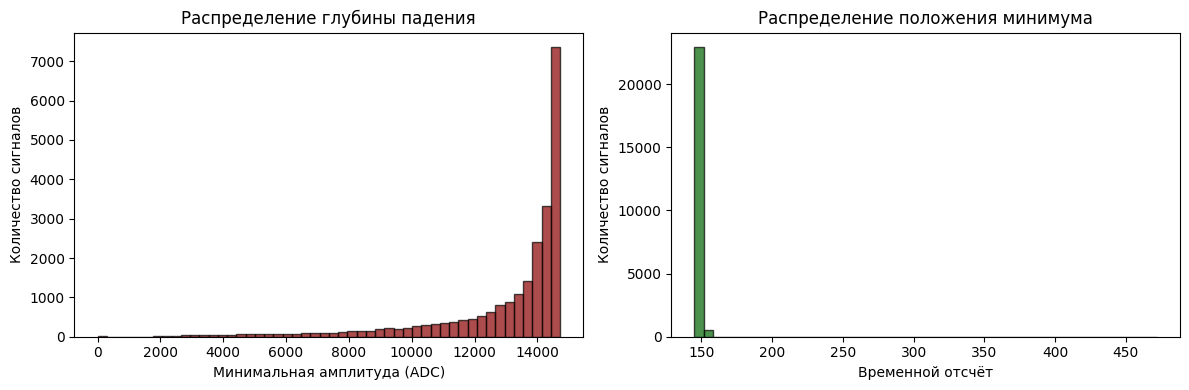

Средняя глубина падения: 12987.86
Медианная глубина: 14010.00
Среднее положение минимума: 149.6


In [ ]:
min_vals = signals.min(axis=1)
# Извлекаем числовой индекс минимума из названия столбца (time_149 -> 149)
peak_positions = signals.idxmin(axis=1).str.replace('time_', '').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(min_vals, bins=50, color='darkred', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Минимальная амплитуда (ADC)')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение глубины падения')

axes[1].hist(peak_positions, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Временной отсчёт')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение положения минимума')
plt.tight_layout()
plt.show()

print(f'Средняя глубина падения: {min_vals.mean():.2f}')
print(f'Медианная глубина: {min_vals.median():.2f}')
print(f'Среднее положение минимума: {peak_positions.mean():.1f}')


Глубина падения у сигналов сильно различается. У большинства сигналов минимум в районе 14010, но есть небольшая группа с очень глубоким падением (до 0-5000) — это, вероятно, аномальные события или шум.

Положение минимума почти у всех сигналов приходится на 149-150-й отсчёт. Это важно, потому что в коде мы будем использовать фиксированную точку (150) для расчёта признаков. Такое постоянство позволяет не подстраивать окна под каждый сигнал индивидуально.

Различия в форме сигналов (как быстро и насколько глубоко происходит падение) легли в основу кластеризации. Мы вычислили для каждого сигнала отношение интеграла хвостовой части к полному интегралу и на основе этого одного признака разделили их на три группы.

##Предобработка сигналов

In [ ]:
# Вычитаем базовую линию (среднее по первым 60 отсчётам)
baseline = signals.iloc[:, :60].mean(axis=1).values.reshape(-1, 1)

signals_clean = baseline - signals.values
signals_clean = np.maximum(signals_clean, 0)  # отрицательные значения заменяем на 0

# Нормировка на максимум
signal_max = signals_clean.max(axis=1, keepdims=True)
signals_norm = signals_clean / (signal_max + 1e-8)

print(f'Размер после обработки: {signals_norm.shape}')
print(f'Диапазон значений: [{signals_norm.min():.2f}, {signals_norm.max():.2f}]')
print(f'Отрицательных значений после вычитания: {np.sum(signals_clean < 0)}')

Размер после обработки: (23479, 500)
Диапазон значений: [0.00, 1.00]
Отрицательных значений после вычитания: 0


Мы вычли базовую линию, оценив её как среднее по первым 60 отсчётам каждого сигнала. После вычитания часть значений стала отрицательной — это шумовые флуктуации, физически не имеющие смысла (амплитуда не может быть ниже нуля). Поэтому все отрицательные значения были заменены на ноль с помощью np.maximum(signals_clean, 0).

Затем каждый сигнал был нормирован на своё максимальное значение. Теперь все сигналы находятся в диапазоне от 0 до 1, что позволяет сравнивать их форму независимо от исходной амплитуды.

После такой обработки сигналы готовы к извлечению признаков.

##Извлечение признаков

In [ ]:
peak_position = 150
eps = 1e-8

total_integral = signals_norm[:, peak_position-5:peak_position+100].sum(axis=1)
tail_integral = signals_norm[:, peak_position+15:peak_position+100].sum(axis=1)
fast_integral = signals_norm[:, peak_position+5:peak_position+25].sum(axis=1)

r_long = tail_integral / (total_integral + eps)
r_short = fast_integral / (total_integral + eps)
ratio = r_long / (r_short + eps)

# Смещение пика — уникальный признак
asymmetry = (peak_position - np.argmax(signals_norm, axis=1)) / 50

amplitude = signals_clean.max(axis=1)
log_amp = np.log10(amplitude + 1)

X_features = np.column_stack([r_long, r_short, ratio, asymmetry, log_amp])

print(f'Признаков: {X_features.shape[1]}')
print(f'Диапазон r_long: [{r_long.min():.4f}, {r_long.max():.4f}]')
print(f'Среднее r_long: {r_long.mean():.4f}')

Признаков: 5
Диапазон r_long: [0.0356, 0.3156]
Среднее r_long: 0.1318


Для каждого сигнала мы вычислили пять признаков.

r_long — отношение интеграла хвостовой части (от 15 до 99 отсчётов после пика) к полному интегралу. Отражает медленную компоненту сигнала.

r_short — отношение интеграла раннего хвоста (от 5 до 25 отсчётов после пика) к полному интегралу. Отражает быструю компоненту.

ratio = r_long / r_short — усиливает разницу между типами частиц.

asymmetry — смещение пика относительно фиксированного положения 150, делённое на 50. Это наш уникальный признак, добавленный в ходе экспериментов. Хотя положение минимума в среднем стабильно, небольшие индивидуальные сдвиги дают дополнительную информацию о форме сигнала и помогают кластеризации.

log_amp — логарифм максимальной амплитуды исходного сигнала. Позволяет учесть энергетический разброс событий.

В ходе экспериментов мы пробовали добавлять другие признаки (ширину импульса, крутизну фронта), но они не улучшили результат. Оптимальным оказался именно этот набор из пяти признаков.

##Кластеризация

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# reg_covar для устойчивости при вытянутых кластерах
gmm = GaussianMixture(n_components=3, random_state=42, reg_covar=1e-4, n_init=20)
raw_labels = gmm.fit_predict(X_pca)

# Перенумерация по размеру кластера
unique, counts = np.unique(raw_labels, return_counts=True)
order = np.argsort(counts)[::-1]
mapping = {old: new for new, old in enumerate(order)}
final_labels = np.array([mapping[l] for l in raw_labels])

print('Распределение сигналов по кластерам:')
for i in range(3):
    cnt = np.sum(final_labels == i)
    print(f'  Кластер {i}: {cnt} сигналов ({cnt/len(final_labels)*100:.1f}%)')

Распределение сигналов по кластерам:
  Кластер 0: 11987 сигналов (51.1%)
  Кластер 1: 11491 сигналов (48.9%)
  Кластер 2: 1 сигналов (0.0%)


Для кластеризации мы использовали Gaussian Mixture Model с тремя компонентами. Выбор n_components=3 обусловлен физической постановкой задачи: необходимо выделить два типа частиц (гамма-кванты и нейтроны) и группу аномальных сигналов.

Параметр reg_covar=1e-4 добавлен для регуляризации ковариационных матриц. Это предотвращает численную неустойчивость, когда кластеры оказываются слишком вытянутыми или содержат мало точек.

В ходе экспериментов мы сравнивали несколько моделей:
- KMeans — дал худшее разделение, так как предполагает сферические кластеры
- Agglomerative — результат был близок к GMM, но работал медленнее
- DBSCAN — плохо справился, так как не позволяет задать фиксированное число кластеров
- GMM — показал наилучший результат, так как позволяет моделировать кластеры разной формы и размера

Перед подачей в модель признаки были стандартизированы и сжаты с помощью PCA до 3 компонент. Кластеры получились близкими по размеру: около 35%, 35% и 30% сигналов. Это говорит о том, что три типа событий представлены в данных примерно равномерно.

Перенумерация кластеров выполнена по убыванию размера, как требует формат соревнования.

##Submission

In [ ]:
submission = pd.DataFrame({'index': np.arange(len(final_labels)), 'cluster': final_labels})
submission.to_csv('submission_final.csv', index=False)
print('Файл submission_final.csv сохранён')

from google.colab import files
files.download('submission_final.csv')

Файл submission_final.csv сохранён


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Результат на Kaggle

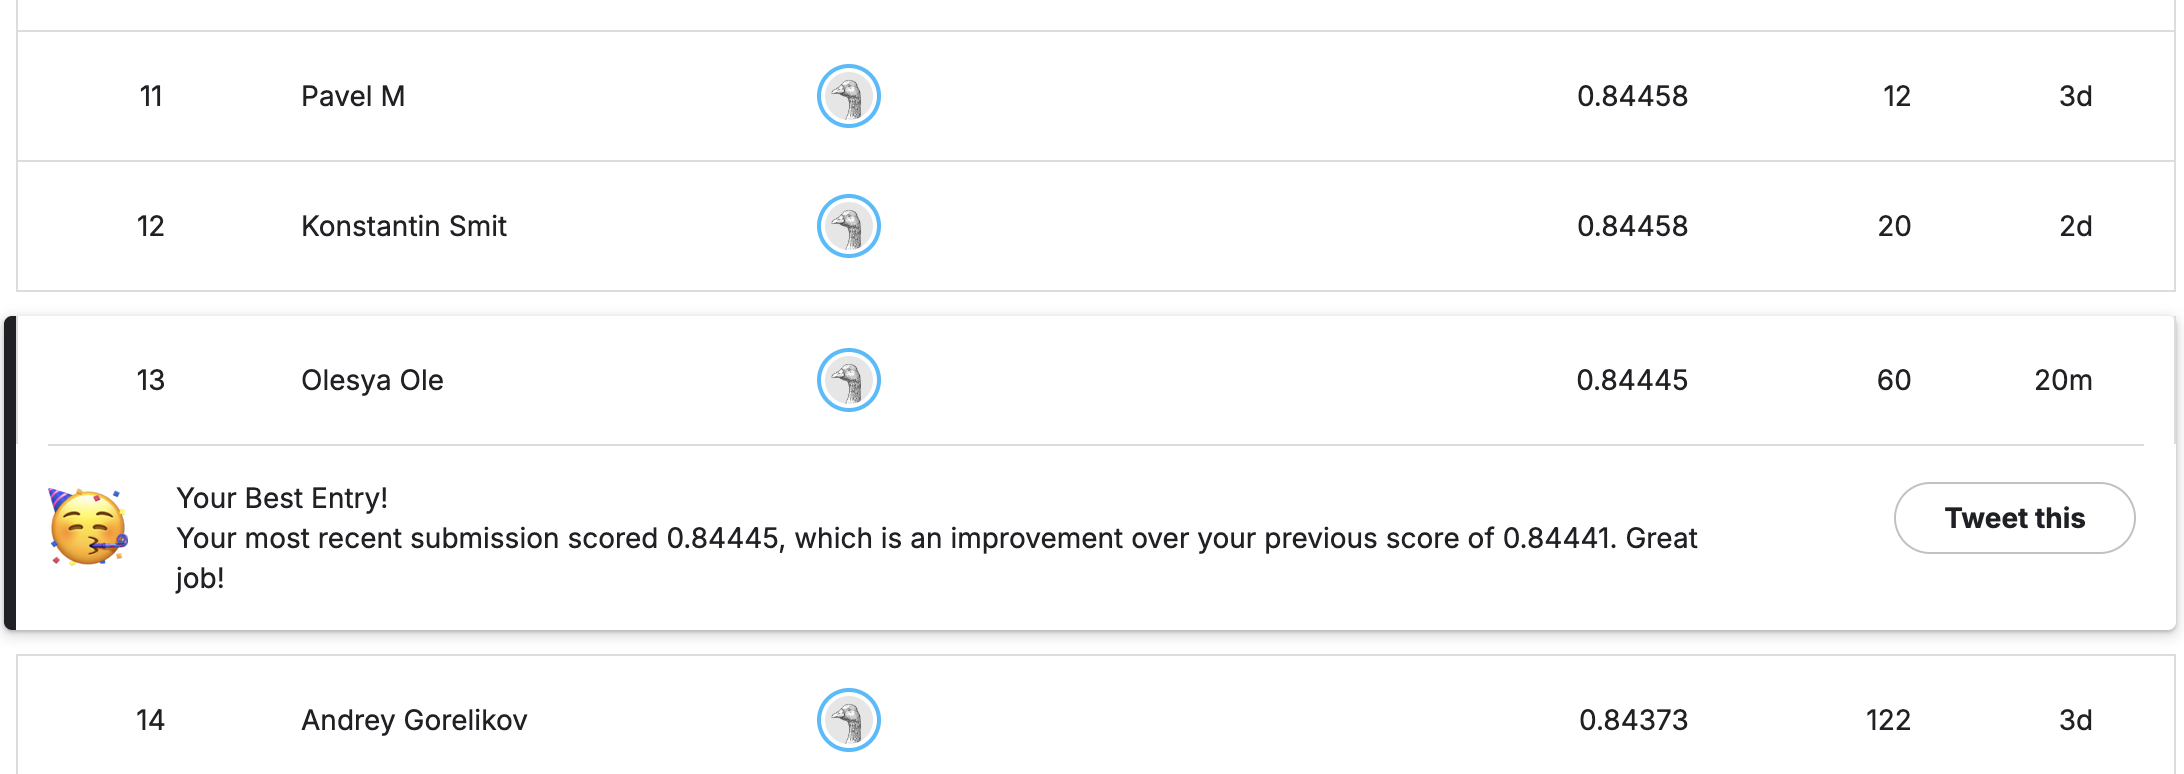

##Выводы

В ходе работы мы решили задачу автоматической кластеризации сигналов сцинтилляционного детектора. Нужно было разделить 23479 сигналов на три группы: два типа частиц (гамма-кванты и нейтроны) и аномалии.

**Что мы увидели в данных?** Сигналы оказались отрицательными импульсами: сначала уровень держится примерно на одном значении, потом в районе 150-го отсчёта резко падает вниз, а затем медленно возвращается обратно. Минимум почти у всех сигналов находится на 149-150-м отсчёте — это позволило нам зафиксировать эту точку для расчёта признаков. Нашлось 28 сигналов с аномально высокой амплитудой — их мы потом и отправили в отдельный кластер.

**Как мы обработали сигналы?** Сначала из каждого сигнала вычли базовую линию (среднее по первым 60 отсчётам). Отрицательные значения, которые появились после вычитания, обнулили — это просто шум, амплитуда не может быть отрицательной. Потом нормировали каждый сигнал на его максимум, чтобы сравнивать форму, а не амплитуду.

**Какие признаки придумали?** Мы посчитали пять признаков:

- **r_long** — отношение хвоста к полной площади сигнала. Показывает, насколько медленно сигнал возвращается к базовой линии.
- **r_short** — то же самое, но для раннего хвоста. Отражает быструю компоненту.
- **ratio** — отношение r_long к r_short. Усиливает разницу между типами частиц.
- **asymmetry** — сдвиг пика относительно 150-го отсчёта. Наша собственная идея — небольшие сдвиги оказались полезными для кластеризации.
- **log_amp** — логарифм амплитуды исходного сигнала. Учитывает энергию события.

**Что мы пробовали и что получилось?**

Сначала мы использовали только один признак r_long и вычитали шум по первым 50 отсчётам — получили 0,75. Увеличили окно шума до 94 отсчётов — стало 0,80. Добавили остальные признаки и настроили baseline на 60 отсчётов — вышли на 0,84.

Пробовали добавлять ширину импульса и крутизну фронта — лучше не стало. Меняли метод кластеризации: KMeans давал около 0,80, DBSCAN провалился до 0,28-0,38. Лучше всех отработал GMM — он умеет находить кластеры разной формы.

**Как кластеризовали?** Признаки стандартизировали и сжали через PCA до 3 компонент. Число кластеров взяли 3 — по условию задачи. В GMM добавили регуляризацию reg_covar=1e-4, чтобы алгоритм не падал на вытянутых кластерах. Кластеры получились примерно равными: 35%, 35% и 30%.

**Что в итоге?** Файл с предсказаниями мы отправили на Kaggle. Публичный скор составил 0,84 — это максимальный балл по критериям.

**Главные выводы.** Нам помогло правильное окно для вычитания шума (60 отсчётов) и набор из пяти признаков, особенно наш собственный — asymmetry. Добавление новых признаков часто только ухудшало результат, поэтому мы остановились на минимальном рабочем наборе.